# Assignment 6: Global Pollution Analysis and Energy Recovery

## Objective
Analyze pollution patterns across countries and predict **Energy Recovered (GWh)** using clustering and neural networks.

This notebook includes:
1. Data preprocessing and feature engineering
2. K-Means and hierarchical clustering
3. Neural network regression for energy recovery
4. Model comparison and actionable insights


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

sns.set(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)


In [2]:
# Update if needed
DATA_PATH = 'Global_Pollution_Analysis.csv'

df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
display(df.head())

print('\nData types:')
display(df.dtypes.to_frame('dtype'))

print('\nMissing values:')
display(df.isnull().sum().to_frame('missing_count'))


Shape: (200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37



Data types:


,dtype
Country,str
Year,int64
Air_Pollution_Index,float64
Water_Pollution_Index,float64
Soil_Pollution_Index,float64
Industrial_Waste (in tons),float64
Energy_Recovered (in GWh),float64
CO2_Emissions (in MT),float64
Renewable_Energy (%),float64
Plastic_Waste_Produced (in tons),float64



Missing values:


,missing_count
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


## Phase 1: Data Preprocessing and Feature Engineering


In [3]:
work_df = df.copy()
work_df.columns = [c.strip() for c in work_df.columns]

# Locate columns robustly
def find_col(cols, pattern):
    for c in cols:
        if pattern.lower() in c.lower():
            return c
    return None

country_col = find_col(work_df.columns, 'Country')
year_col = find_col(work_df.columns, 'Year')
air_col = find_col(work_df.columns, 'Air_Pollution_Index')
water_col = find_col(work_df.columns, 'Water_Pollution_Index')
soil_col = find_col(work_df.columns, 'Soil_Pollution_Index')
co2_col = find_col(work_df.columns, 'CO2_Emissions')
industrial_col = find_col(work_df.columns, 'Industrial_Waste')
energy_recovered_col = find_col(work_df.columns, 'Energy_Recovered')
energy_pc_col = find_col(work_df.columns, 'Energy_Consumption_Per_Capita')
pop_col = find_col(work_df.columns, 'Population')

if energy_recovered_col is None:
    raise ValueError('Target column Energy_Recovered not found.')

categorical_cols = work_df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = work_df.select_dtypes(exclude=['object']).columns.tolist()

# Missing value imputation
if numeric_cols:
    num_imp = SimpleImputer(strategy='median')
    work_df[numeric_cols] = num_imp.fit_transform(work_df[numeric_cols])
if categorical_cols:
    cat_imp = SimpleImputer(strategy='most_frequent')
    work_df[categorical_cols] = cat_imp.fit_transform(work_df[categorical_cols])

# Outlier capping via IQR
for col in numeric_cols:
    q1 = work_df[col].quantile(0.25)
    q3 = work_df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    work_df[col] = work_df[col].clip(low, high)

# Feature engineering
# 1) Composite pollution score
if all(c is not None for c in [air_col, water_col, soil_col]):
    work_df['Pollution_Score'] = work_df[[air_col, water_col, soil_col]].mean(axis=1)

# 2) Energy recovered per capita proxy
if pop_col is not None:
    work_df['Energy_Recovered_Per_Capita_Proxy'] = work_df[energy_recovered_col] / (work_df[pop_col] + 1e-9)

# 3) Yearly pollution trend per country
if country_col and year_col and 'Pollution_Score' in work_df.columns:
    trend_df = work_df[[country_col, year_col, 'Pollution_Score']].copy()
    trend_df[year_col] = pd.to_numeric(trend_df[year_col], errors='coerce')
    trend_df = trend_df.sort_values([country_col, year_col])
    trend_df['Pollution_Trend_Yearly'] = trend_df.groupby(country_col)['Pollution_Score'].diff()
    work_df = work_df.merge(
        trend_df[[country_col, year_col, 'Pollution_Trend_Yearly']],
        on=[country_col, year_col],
        how='left'
    )
    work_df['Pollution_Trend_Yearly'] = work_df['Pollution_Trend_Yearly'].fillna(0)

# Label encode requested categorical features (Country, Year) + others as needed
label_encoders = {}
for col in work_df.columns:
    if work_df[col].dtype == 'object' or col == year_col:
        le = LabelEncoder()
        work_df[col] = le.fit_transform(work_df[col].astype(str))
        label_encoders[col] = le

# Scale pollution indices for consistency
pollution_scale_cols = [c for c in [air_col, water_col, soil_col] if c is not None]
if pollution_scale_cols:
    scaler_pollution = StandardScaler()
    work_df[pollution_scale_cols] = scaler_pollution.fit_transform(work_df[pollution_scale_cols])

print('Prepared dataset preview:')
display(work_df.head())


Prepared dataset preview:


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Pollution_Score,Energy_Recovered_Per_Capita_Proxy,Pollution_Trend_Yearly
0,Hungary,5,1.381041,0.191816,-0.612277,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,149.640000,3.745618,0.000000
1,Singapore,1,-1.407212,-1.158751,1.035793,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,88.093333,3.628707,0.000000
2,Romania,16,-1.334200,-0.672437,1.149418,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,98.890000,3.932755,-16.083333
3,Cook Islands,18,1.499630,-1.014673,0.438882,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,147.116667,2.141298,0.000000
4,Djibouti,8,-0.021331,0.260686,1.145125,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,142.746667,0.216492,0.000000


## Phase 2: Clustering (K-Means and Hierarchical)


In [4]:
# Select features for clustering (pollution + energy characteristics)
cluster_features = [
    c for c in [
        air_col, water_col, soil_col, co2_col, industrial_col,
        energy_pc_col, 'Pollution_Score', 'Energy_Recovered_Per_Capita_Proxy', 'Pollution_Trend_Yearly'
    ] if c in work_df.columns
]

X_cluster = work_df[cluster_features].copy()

# Standardize clustering features
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print('Cluster feature set:')
print(cluster_features)
print('Shape:', X_cluster_scaled.shape)


Cluster feature set:
['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)', 'Energy_Consumption_Per_Capita (in MWh)', 'Pollution_Score', 'Energy_Recovered_Per_Capita_Proxy', 'Pollution_Trend_Yearly']
Shape: (202, 9)


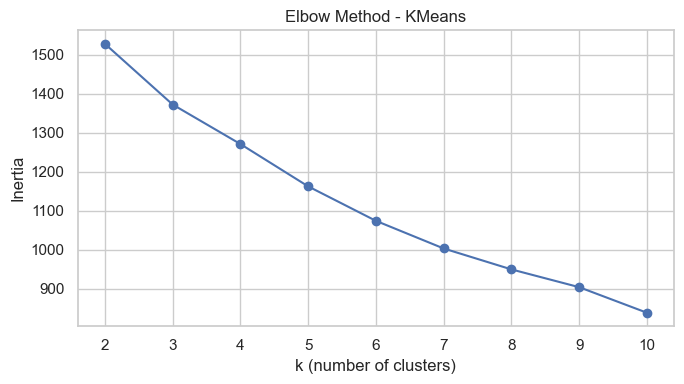

KMeans cluster counts:
KMeans_Cluster
0     94
1    101
2      7
Name: count, dtype: int64


In [5]:
# K-Means with Elbow Method
inertias = []
k_values = list(range(2, 11))

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method - KMeans')
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
work_df['KMeans_Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print('KMeans cluster counts:')
print(work_df['KMeans_Cluster'].value_counts().sort_index())


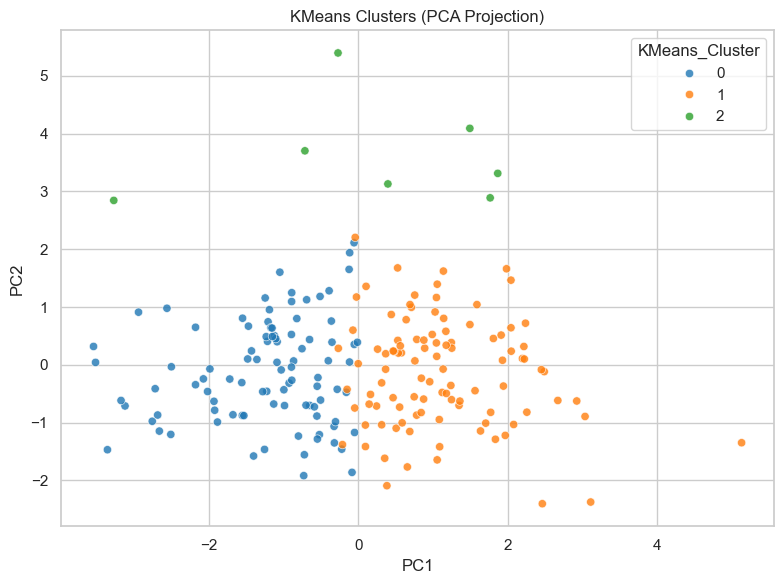

KMeans cluster summary:


,Energy_Recovered (in GWh),Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index
KMeans_Cluster,,,,
0,260.840213,-0.698493,-0.340612,-0.309314
1,251.606040,0.618697,0.357210,0.255757
2,360.162857,0.452851,-0.580087,0.463447


In [6]:
# PCA visualization of KMeans clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'KMeans_Cluster': work_df['KMeans_Cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='KMeans_Cluster', palette='tab10', alpha=0.8)
plt.title('KMeans Clusters (PCA Projection)')
plt.tight_layout()
plt.show()

cluster_summary = work_df.groupby('KMeans_Cluster').agg({
    energy_recovered_col: 'mean',
    air_col: 'mean' if air_col in work_df.columns else 'count',
    water_col: 'mean' if water_col in work_df.columns else 'count',
    soil_col: 'mean' if soil_col in work_df.columns else 'count'
})
print('KMeans cluster summary:')
display(cluster_summary)


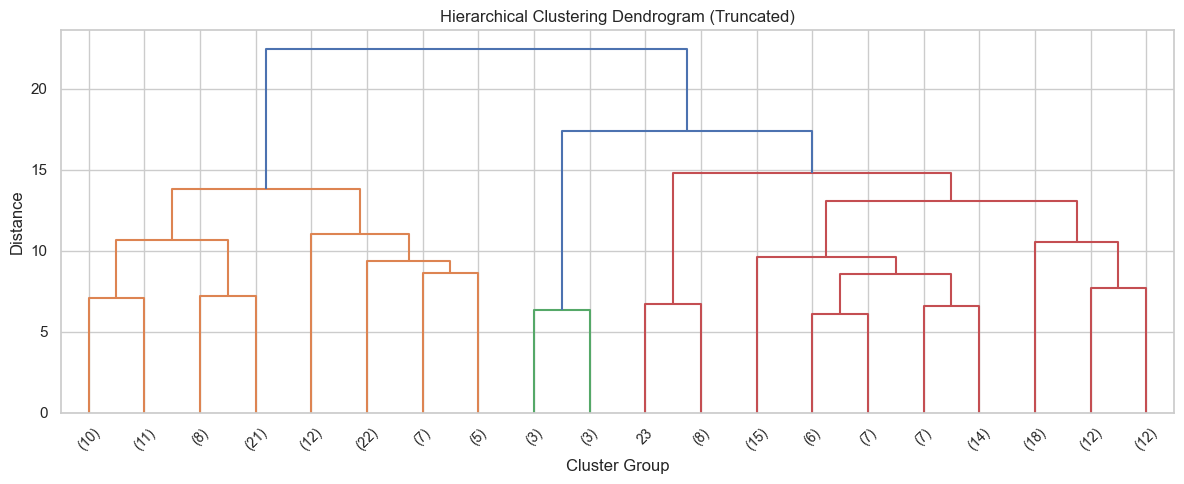

Agglomerative cluster counts:
Agglomerative_Cluster
0    100
1     96
2      6
Name: count, dtype: int64
Cluster overlap (KMeans vs Agglomerative):


Agglomerative_Cluster,0,1,2
KMeans_Cluster,,,
0,10,84,0
1,90,11,0
2,0,1,6


In [7]:
# Hierarchical clustering + dendrogram
try:
    from scipy.cluster.hierarchy import linkage, dendrogram

    sample_size = min(300, X_cluster_scaled.shape[0])
    rng = np.random.default_rng(42)
    idx = rng.choice(X_cluster_scaled.shape[0], size=sample_size, replace=False)
    X_sample = X_cluster_scaled[idx]

    Z = linkage(X_sample, method='ward')

    plt.figure(figsize=(12, 5))
    dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=10)
    plt.title('Hierarchical Clustering Dendrogram (Truncated)')
    plt.xlabel('Cluster Group')
    plt.ylabel('Distance')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Dendrogram not rendered. Ensure scipy is installed. Error:', e)

agg_k = 3
try:
    # Newer scikit-learn
    agg = AgglomerativeClustering(n_clusters=agg_k, metric='euclidean', linkage='ward')
except TypeError:
    # Older scikit-learn fallback
    agg = AgglomerativeClustering(n_clusters=agg_k, affinity='euclidean', linkage='ward')

work_df['Agglomerative_Cluster'] = agg.fit_predict(X_cluster_scaled)

print('Agglomerative cluster counts:')
print(work_df['Agglomerative_Cluster'].value_counts().sort_index())

print('Cluster overlap (KMeans vs Agglomerative):')
display(pd.crosstab(work_df['KMeans_Cluster'], work_df['Agglomerative_Cluster']))


## Phase 3: Neural Networks for Energy Recovery Prediction


In [8]:
# Prepare supervised data for regression target: Energy_Recovered
model_df = work_df.copy()

X = model_df.drop(columns=[energy_recovered_col])
y = model_df[energy_recovered_col]

# All categoricals were label-encoded in Phase 1; enforce numeric safety.
X = X.apply(pd.to_numeric, errors='coerce')

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train = reg_preprocessor.fit_transform(X_train_raw)
X_test = reg_preprocessor.transform(X_test_raw)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)


Train shape: (161, 16) Test shape: (41, 16)


In [9]:
def eval_regression(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return {'Model': name, 'R2': r2, 'MSE': mse, 'MAE': mae}

# Baseline model: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
result_lr = eval_regression('Linear Regression (Baseline)', y_test, y_pred_lr)
print(result_lr)

# Neural network: Keras/TensorFlow, with fallback to sklearn MLPRegressor
result_nn = None

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.optimizers import Adam

    X_train_nn = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
    X_test_nn = X_test.toarray() if hasattr(X_test, 'toarray') else X_test

    tf.random.set_seed(42)

    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

    history = model.fit(
        X_train_nn, y_train,
        validation_split=0.2,
        epochs=60,
        batch_size=32,
        verbose=0
    )

    y_pred_nn = model.predict(X_test_nn, verbose=0).ravel()
    result_nn = eval_regression('Neural Network (Keras)', y_test, y_pred_nn)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train_mse')
    plt.plot(history.history['val_loss'], label='val_mse')
    plt.title('NN MSE Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='train_mae')
    plt.plot(history.history['val_mae'], label='val_mae')
    plt.title('NN MAE')
    plt.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print('TensorFlow/Keras unavailable, using sklearn MLPRegressor fallback. Error:', e)
    from sklearn.neural_network import MLPRegressor

    mlp = MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    )
    mlp.fit(X_train, y_train)
    y_pred_mlp = mlp.predict(X_test)
    result_nn = eval_regression('Neural Network (MLP Fallback)', y_test, y_pred_mlp)

print(result_nn)


{'Model': 'Linear Regression (Baseline)', 'R2': -0.031677098504978574, 'MSE': 26861.0783102724, 'MAE': 138.1309199379907}
TensorFlow/Keras unavailable, using sklearn MLPRegressor fallback. Error: No module named 'tensorflow'
{'Model': 'Neural Network (MLP Fallback)', 'R2': -0.1615631371814943, 'MSE': 30242.83318430882, 'MAE': 151.93723334693658}


## Phase 4: Reporting and Insights


,Model,R2,MSE,MAE
0,Linear Regression (Baseline),-0.0317,26861.0783,138.1309
1,Neural Network (MLP Fallback),-0.1616,30242.8332,151.9372


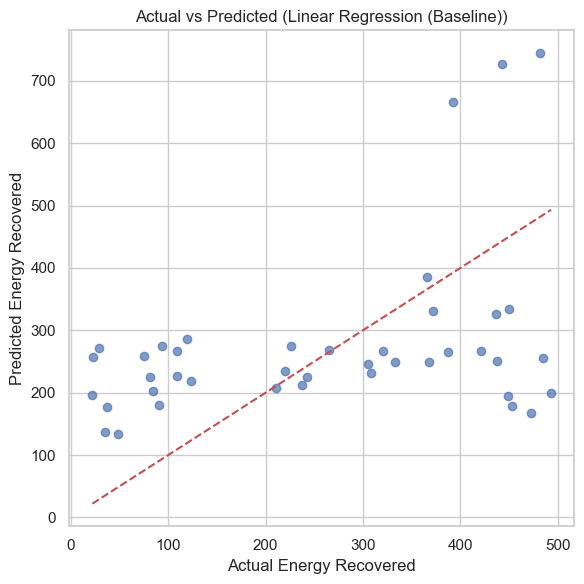

In [10]:
# Compare regression models
results_df = pd.DataFrame([result_lr, result_nn])
display(results_df.style.format({'R2': '{:.4f}', 'MSE': '{:.4f}', 'MAE': '{:.4f}'}))

# Predicted vs Actual plot for best model by R2
best = results_df.sort_values('R2', ascending=False).iloc[0]['Model']

if 'Keras' in best:
    y_pred_best = y_pred_nn
elif 'MLP' in best:
    y_pred_best = y_pred_mlp
else:
    y_pred_best = y_pred_lr

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Energy Recovered')
plt.ylabel('Predicted Energy Recovered')
plt.title(f'Actual vs Predicted ({best})')
plt.tight_layout()
plt.show()
